# California Housing Prices Prediction
> Learning project following *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* by
**Aurélien Géron** (Chapter 2).

## 1. Frame the Problem & Objectives
* **Dataset**: [California Housing Dataset](https://github.com/ageron/data/tree/main/housing) (1990 California census data).
* **Target**: Predict a district's **median house value**.

### Key Observations & Design Decisions
* **Supervised Learning**: Target labels are available in the training data.
* **Multiple Univariate Regression**: Uses multiple predictor features (income, location, total rooms, etc.) to predict a single continuous output.
* **Batch Learning**: Small static dataset with no continuous incoming data stream.
* **Performance Measure**: **RMSE** (Root Mean Squared Error) will be used as the evaluation metric.

In [4]:
#Load the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import colorbar
from pandas import DataFrame
import seaborn as sns

### Load data
* I have loaded data from the url link provided in the code as downloading data and statically importing it is not good practice. What I have done is (as given is book):
    * I check if the data already exists or not.
    * if it does then well just read it.
    * if not then download .tgz archive from link and then extract it.

In [5]:
#import needed for below function
#for path defining
from pathlib import Path
#to extract data

import tarfile
#to retrieve data from given url
import urllib.request

In [6]:
# function to load the data

def load_housing_data() ->  DataFrame:
    #define zip file path
    zip_path = Path('data/housing_data.tgz')
    if not zip_path.is_file():

        #if zip path not found
        #make data directory if it doesn't exist
        Path('data').mkdir(parents=True , exist_ok=True)

        #data on web
        url = 'https://github.com/ageron/data/raw/main/housing.tgz'

        #retrieve the file in zip_path location
        urllib.request.urlretrieve(url , zip_path)

        #extract the data bcs this is first load so this is done inside if condition
        with tarfile.open(zip_path) as housing_zip:
            housing_zip.extractall(path='data',filter='data')

    #return the dataframe
    return pd.DataFrame(pd.read_csv(Path("data/housing/housing.csv")))


In [7]:
#Load data in var
housing_df = load_housing_data()

### EDA (exploratory data analysis)
#### Try to understand the Data

In [8]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [9]:
#column info
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
# finding null values
housing_df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [11]:
# analyzing categories in the ocean_proximity
#counting value for each unique category
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [12]:
#summary statistics using describe()
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### Observations
* total 10 features 9 input and 1 target
* column 'total_bedrooms' contain 207 null/missing values
* One categorical Column 'ocean_proximity' with labels : ['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
* Target column is 'median_house_value'
* 'median_income' is preprocessed scaled so that 3 is roughly equal to \$30000.

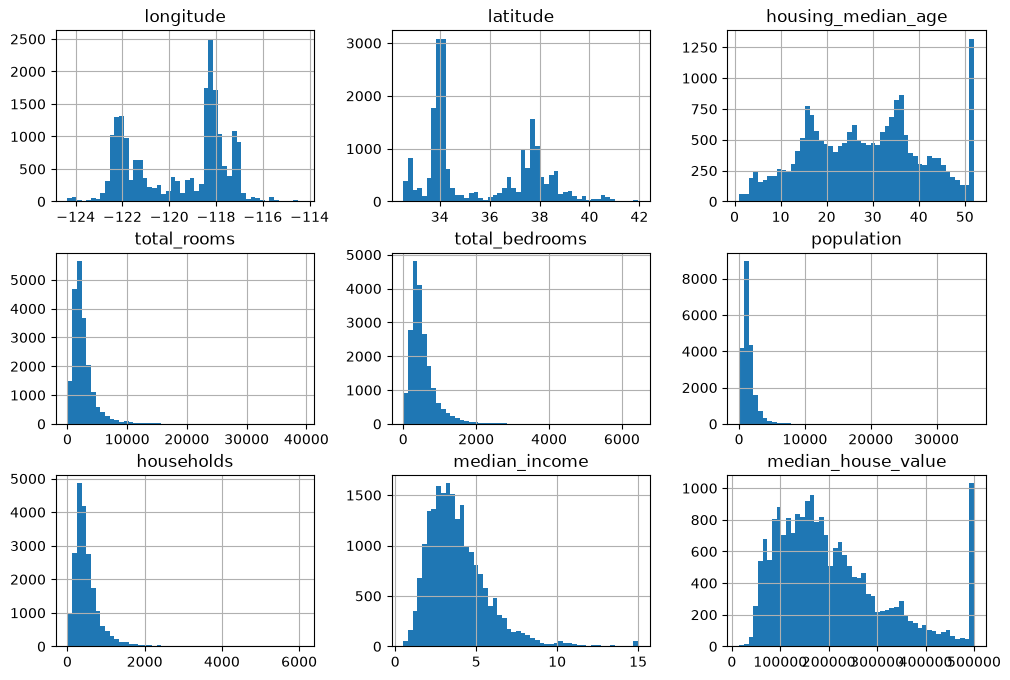

In [13]:
#analyzing each numerical columns using histo grams
housing_df.hist(bins=50 , figsize=(12,8))
plt.show()

### Splitting the Data

* when trying to split the data we can use train_test_split() of sklearn but this function creates the test set with complete randomness
* This is okay for most of the models but the real problem is that it is not gurenteed that the test split represents the data accurately.

* **What would be the best approach?**
    * For example, we have a dataset having 54 % male and 46% females in it.
    * So, for a test split the ideal sample will be the sample in which the percentage of the male and female is same as in total population
    * i.e. for a sample of 1000 it would be better if it has near to 540 males and 460 females.
    * **This splitting is Know as _stratified sampling_**
<br>
* Now, in book it is recommended and is also obvious that the `median_income` column is very important attribute to predict the target. So,we make sure the test is representative of the given attribute.

* To achieve this will split make a categorical attribute `income_cat` which represents income category with binwidth = 1.5 roughly \$15,000.

* Based on this attribute we will stratify the test split as given in below code cell.

**Note :-**
* We can try to make a function which gives use n number of this train test split; which may be helpful in the feature.
 * for reference see HOML book page 61 .

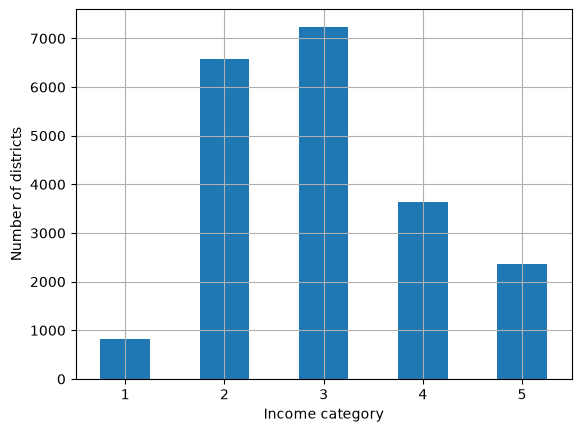

In [14]:
#making 'income_cat' column
housing_df['income_cat'] = pd.cut(housing_df['median_income'] ,
                                  bins = [0 , 1.5 , 3.0 , 4.5 , 6.0 , max(housing_df['median_income'])],
                                  labels = [1,2,3,4,5])

## To see the distribution of the income in different bins ##
#return the categories
cat_counts = housing_df['income_cat'].value_counts().sort_index()
cat_counts.plot.bar(rot =0 ,grid = True)
plt.xlabel('Income category')
plt.ylabel('Number of districts')
plt.show()

In [15]:
#train test split
from sklearn.model_selection import train_test_split

train_data , test_data = train_test_split(housing_df , test_size=0.2, stratify=housing_df['income_cat'], random_state=42)

#better to drop 'income_cat' as it has no use now

train_data.drop('income_cat' , axis = 1, inplace = True)
test_data.drop('income_cat' , axis = 1, inplace = True)

# copy to experiment on
train_data_c= train_data.copy()
test_data_c= test_data.copy()

In [16]:
# function for multiple tarin_test_splits

from sklearn.model_selection import StratifiedShuffleSplit

#making this usable by using these arguments rather than hardcoding it
def strat_train_test_multiple(df: pd.DataFrame , split_col: str , n: int = 10):
    splitter = StratifiedShuffleSplit(n_splits=n ,
                                      test_size=0.2,
                                      random_state=42)

    strat_splits = []

    #split() return the idx of the train and test splits only
    for train_idx,test_idx in splitter.split(df ,
                                       df[split_col]):
        #splitting by index returned
        strat_train_set_n = df.iloc[train_idx]
        strat_test_set_n = df.iloc[test_idx]
        #used tuple to pack them.
        strat_splits.append((strat_train_set_n,strat_test_set_n))

    return strat_splits

#### Correlation analysis
* A correlation analysis is a very important part in EDA where learn how the variables depend on each other.
* i.e. how change in one variable affects change in the other variable.
* We will use pearsons correlation coefficient which helps identify the linear relationship between two numeric features. But, it ignores any non-linear relationship in vars.
* its value is between -1 and 1. The closer it is to 1 or -1 the linear relationship is also strong and closer it is to zero less correlation between features.
* This part is very helpful in feature engineering.
* We will build a correlation matrix for this and correlation of each input features to the output feature.

**Note :-**
* We can also do correlation analysis using scatter plots.
* I am skipping that part which is given in the book.

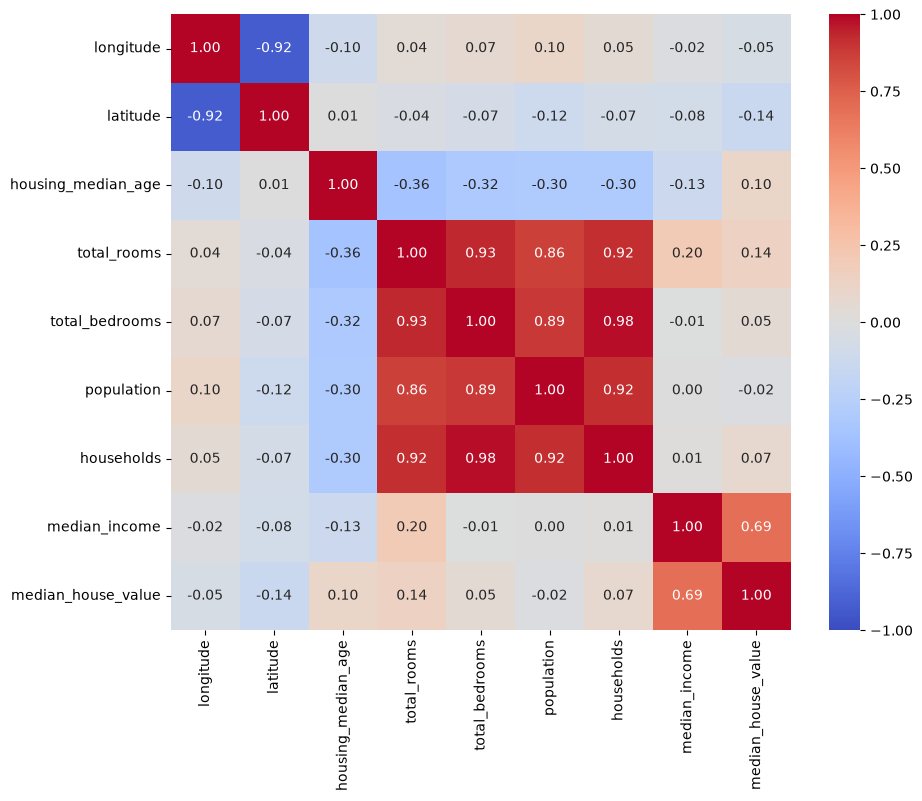

In [24]:
# all analysis in training data

plt.figure(figsize=(10,8))

corr_matrix = train_data_c.corr(numeric_only=True)

# Heat map for better appealing visuals
sns.heatmap(corr_matrix , annot=True , cmap='coolwarm' , fmt = '.2f' , vmin = -1 , vmax = 1)

plt.show()

* We came to know that whole correlation matrix is very overwhelmin to look at.
* The solution is to find the features which are more related to the target then fing correlation between those main features.

In [22]:
# find each feature corr with median_house_value
print(corr_matrix['median_house_value'].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


* the Features are not very correlated.
* The top most features that will be useful for prediction of the target will be `median_income`,`total_rooms` ,`housing_median_age` and `latitude`.
* Taken features having corr > 0.1

### Feature Engineering